# Recommendation System Project: IBM Community



## Table of Contents

I. [Exploratory Data Analysis](#Exploratory-Data-Analysis)<br>
II. [Rank Based Recommendations](#Rank)<br>
III. [User-User Based Collaborative Filtering](#User-User)<br>
IV. [Content Based Recommendations](#Content-Recs)<br>
V. [Matrix Factorization](#Matrix-Fact)<br>



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import project_tests as t


df = pd.read_csv(
    'data/user-item-interactions.csv', 
    dtype={'article_id': int, 'title': str, 'email': str}
)
# Show df to get an idea of the data
df.head()

,Unnamed: 0,article_id,title,email
0,0,1430,"using pixiedust for fast, flexible, and easier...",ef5f11f77ba020cd36e1105a00ab868bbdbf7fe7
1,1,1314,healthcare python streaming application demo,083cbdfa93c8444beaa4c5f5e0f5f9198e4f9e0b
2,2,1429,use deep learning for image classification,b96a4f2e92d8572034b1e9b28f9ac673765cd074
3,3,1338,ml optimization using cognitive assistant,06485706b34a5c9bf2a0ecdac41daf7e7654ceb7
4,4,1276,deploy your python model as a restful api,f01220c46fc92c6e6b161b1849de11faacd7ccb2


### <a class="anchor" id="Exploratory-Data-Analysis">Part I : Exploratory Data Analysis</a>

Use the dictionary and cells below to provide some insight into the descriptive statistics of the data.

`1.` Are there any missing values? If so, provide a count of missing values. If there are missing values in `email`, assign it the same id value `"unknown_user"`.

In [2]:
# Some interactions do not have a user associated with it, assume the same user.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45993 entries, 0 to 45992
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  45993 non-null  int64 
 1   article_id  45993 non-null  int32 
 2   title       45993 non-null  object
 3   email       45976 non-null  object
dtypes: int32(1), int64(1), object(2)
memory usage: 1.2+ MB


In [3]:
# Count missing email values
null_email_count = df['email'].isnull().sum()

print(f"Number of Null email values is: {null_email_count}")

Number of Null email values is: 17


In [4]:
df[df.email.isna()]

,Unnamed: 0,article_id,title,email
25131,25146,1016,why you should master r (even if it might even...,NaN
29758,30157,1393,the nurse assignment problem,NaN
29759,30158,20,working interactively with rstudio and noteboo...,NaN
29760,30159,1174,breast cancer wisconsin (diagnostic) data set,NaN
29761,30160,62,data visualization: the importance of excludin...,NaN
35264,36016,224,"using apply, sapply, lapply in r",NaN
35276,36029,961,beyond parallelize and collect,NaN
35277,36030,268,sector correlations shiny app,NaN
35278,36031,268,sector correlations shiny app,NaN
35279,36032,268,sector correlations shiny app,NaN


In [5]:
# Fill email NaNs with "unknown_user"
df['email'] = df['email'].fillna('unknown_user')

In [6]:
# Check if no more NaNs 
df[df.email.isna()]

,Unnamed: 0,article_id,title,email


`2.` What is the distribution of how many articles a user interacts with in the dataset?  Provide a visual and descriptive statistics to assist with giving a look at the number of times each user interacts with an article.

In [7]:
# What are the descriptive statistics of the number of articles a user interacts with?
# Number of articles each user interacts with
user_article_counts = df.groupby('email')['article_id'].count()

# Descriptive statistics
print(user_article_counts.describe())

count    5149.000000
mean        8.932414
std        16.801011
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       364.000000
Name: article_id, dtype: float64


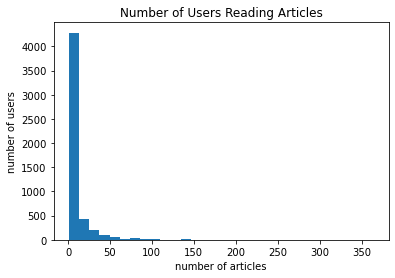

In [8]:
# Create a plot of the number of articles read by each user
plt.hist(user_article_counts, bins=30)
plt.xlabel('number of articles')
plt.ylabel('number of users')
plt.title('Number of Users Reading Articles')
plt.show()

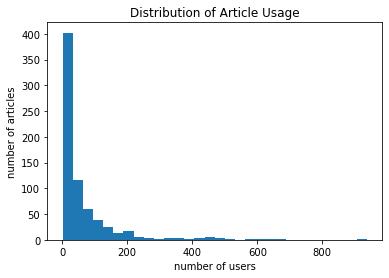

In [9]:
# Create a plot of the number of times each article was read
# Number of times each article was read
article_read_counts = df.groupby('article_id')['email'].count()

plt.hist(article_read_counts, bins=30)
plt.xlabel('number of users')
plt.ylabel('number of articles')
plt.title('Distribution of Article Usage')
plt.show()

In [10]:
# Fill in the median and maximum number of user_article interactions below

# 50% of individuals interact with ____ number of articles or fewer.
median_val =  user_article_counts.median()

# The maximum number of user-article interactions by any 1 user is ______.
max_views_by_user =  user_article_counts.max()

`3.` Use the cells below to find:

**a.** The number of unique articles that have an interaction with a user.  
**b.** The number of unique articles in the dataset (whether they have any interactions or not).<br>
**c.** The number of unique users in the dataset. (excluding null values) <br>
**d.** The number of user-article interactions in the dataset.

In [11]:
# The number of unique articles that have at least one interaction
unique_articles = df['article_id'].nunique()

# The number of unique articles on the IBM platform
total_articles = df['article_id'].nunique()

# The number of unique users
unique_users = df['email'].nunique()

# The number of user-article interactions
user_article_interactions = df.shape[0]

`4.` Use the cells below to find the most viewed **article_id**, as well as how often it was viewed.  After talking to the company leaders, the `email_mapper` function was deemed a reasonable way to map users to ids.  There were a small number of null values, and it was found that all of these null values likely belonged to a single user (which is how they are stored using the function below).

In [12]:
# The most viewed article id (as a string with one decimal place)
most_viewed_article_id = df['article_id'].value_counts().idxmax()


# The number of times it was viewed
max_views = df['article_id'].value_counts().max()

In [13]:
## No need to change the code here - this will be helpful for later parts of the notebook
# Run this cell to map the user email to a user_id column and remove the email column

def email_mapper(df=df):
    coded_dict = {
        email: num 
        for num, email in enumerate(df['email'].unique(), start=1)
    }
    return [coded_dict[val] for val in df['email']]

df['user_id'] = email_mapper(df)
del df['email']

# show header
df.head()

,Unnamed: 0,article_id,title,user_id
0,0,1430,"using pixiedust for fast, flexible, and easier...",1
1,1,1314,healthcare python streaming application demo,2
2,2,1429,use deep learning for image classification,3
3,3,1338,ml optimization using cognitive assistant,4
4,4,1276,deploy your python model as a restful api,5


In [14]:
## If you stored all your results in the variable names above, 
## you shouldn't need to change anything in this cell

sol_1_dict = {
    '`50% of individuals have _____ or fewer interactions.`': median_val,
    '`The total number of user-article interactions in the dataset is ______.`': user_article_interactions,
    '`The maximum number of user-article interactions by any 1 user is ______.`': max_views_by_user,
    '`The most viewed article in the dataset was viewed _____ times.`': max_views,
    '`The article_id of the most viewed article is ______.`': most_viewed_article_id,
    '`The number of unique articles that have at least 1 rating ______.`': unique_articles,
    '`The number of unique users in the dataset is ______`': unique_users,
    '`The number of unique articles on the IBM platform`': total_articles
}

# Test your dictionary against the solution
t.sol_1_test(sol_1_dict)

It looks like you have everything right here! Nice job!


### <a class="anchor" id="Rank">Part II: Rank-Based Recommendations</a>

In this project, we don't actually have ratings for whether a user liked an article or not.  We only know that a user has interacted with an article. In these cases, the popularity of an article can really only be based on how often an article was interacted with.

`1.` Fill in the function below to return the **n** top articles ordered with most interactions as the top. Test your function using the tests below.

In [15]:
def get_top_articles(n, df=df):
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article titles 
    
    """
    # Get top n article_ids by interaction count
    top_article_ids = df['article_id'].value_counts().head(n).index
    
    # Get corresponding titles
    top_articles = df[df['article_id'].isin(top_article_ids)] \
                     .drop_duplicates('article_id') \
                     .set_index('article_id') \
                     .loc[top_article_ids]['title'] \
                     .tolist()
    
    
    return top_articles # Return the top article titles from df

def get_top_article_ids(n, df=df):
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article titles 
    
    """
    top_articles = df['article_id'].value_counts().head(n).index.tolist()
 
    return top_articles # Return the top article ids

In [16]:
print(get_top_articles(10))
print(get_top_article_ids(10))

['use deep learning for image classification', 'insights from new york car accident reports', 'visualize car data with brunel', 'use xgboost, scikit-learn & ibm watson machine learning apis', 'predicting churn with the spss random tree algorithm', 'healthcare python streaming application demo', 'finding optimal locations of new store using decision optimization', 'apache spark lab, part 1: basic concepts', 'analyze energy consumption in buildings', 'gosales transactions for logistic regression model']
[1429, 1330, 1431, 1427, 1364, 1314, 1293, 1170, 1162, 1304]


In [17]:
# Test your function by returning the top 5, 10, and 20 articles
top_5 = get_top_articles(5)
top_10 = get_top_articles(10)
top_20 = get_top_articles(20)

# Test each of your three lists from above
t.sol_2_test(get_top_articles)

Your top_5 looks like the solution list! Nice job.
Your top_10 looks like the solution list! Nice job.
Your top_20 looks like the solution list! Nice job.


### <a class="anchor" id="User-User">Part III: User-User Based Collaborative Filtering</a>


`1.` Use the function below to reformat the **df** dataframe to be shaped with users as the rows and articles as the columns.  

* Each **user** should only appear in each **row** once.


* Each **article** should only show up in one **column**.  


* **If a user has interacted with an article, then place a 1 where the user-row meets for that article-column**.  It does not matter how many times a user has interacted with the article, all entries where a user has interacted with an article should be a 1.  


* **If a user has not interacted with an item, then place a zero where the user-row meets for that article-column**. 

Use the tests to make sure the basic structure of your matrix matches what is expected by the solution.

In [18]:
# create the user-article matrix with 1's and 0's

def create_user_item_matrix(df, fill_value=0):
    """
    INPUT:
    df - pandas dataframe with article_id, title, user_id columns
    
    OUTPUT:
    user_item - user item matrix 
    
    Description:
    Return a matrix with user ids as rows and article ids on the columns with 1 values where a user interacted with 
    an article and a 0 otherwise
    """
    # Fill in the function here
    
    user_item = df.groupby(['user_id', 'article_id'])['title'] \
              .count() \
              .unstack() \
              .fillna(fill_value)
    
    # Convert counts to 1 (interaction exists)
    user_item = user_item.applymap(lambda x: 1 if x > 0 else 0)
    
    return user_item # return the user_item matrix 

user_item = create_user_item_matrix(df)

In [19]:
## Tests: You should just need to run this cell.  Don't change the code.
assert user_item.shape[0] == 5149, "Oops!  The number of users in the user-article matrix doesn't look right."
assert user_item.shape[1] == 714, "Oops!  The number of articles in the user-article matrix doesn't look right."
assert user_item.sum(axis=1)[1] == 36, "Oops!  The number of articles seen by user 1 doesn't look right."
print("You have passed our quick tests!  Please proceed!")

You have passed our quick tests!  Please proceed!


`2.` Complete the function below which should take a user_id and provide an ordered list of the most similar users to that user (from most similar to least similar).  The returned result should not contain the provided user_id, as we know that each user is similar to him/herself. Because the results for each user here are binary, it (perhaps) makes sense to compute similarity as the dot product of two users. 

Use the tests to test your function.

In [20]:
# Lets use the cosine_similarity function from sklearn
from sklearn.metrics.pairwise import cosine_similarity

In [21]:
def find_similar_users(user_id, user_item=user_item, include_similarity=False):
    """
    INPUT:
    user_id - (int) a user_id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    include_similarity - (bool) whether to include the similarity in the output
    
    OUTPUT:
    similar_users - (list) an ordered list where the closest users (largest dot product users)
                    are listed first
    
    Description:
    Computes the similarity of every pair of users based on the dot product
    Returns an ordered list of user ids. If include_similarity is True, returns a list of lists
    where the first element is the user id and the second the similarity.
    
    """
    
    # compute cosine similarity of all users to the provided user
    similarity = cosine_similarity(user_item, user_item.loc[[user_id]])
    
    # flatten similarity array
    similarity = similarity.flatten()
    
    # convert to pandas Series with user_id index
    similarity = pd.Series(similarity, index=user_item.index)
    
    # sort by similarity
    similarity = similarity.sort_values(ascending=False)
    
    # remove the own user's id
    similarity = similarity.drop(user_id)
    
    # create list of just the ids
    most_similar_users = similarity.index.tolist()
    
    # create list of just the similarities
    if include_similarity:
        return [[uid, similarity.loc[uid]] for uid in most_similar_users] # return a list of lists with [[similar_user_id, similarity], ...]
    
    return most_similar_users # return a list of the users in order from most to least similar
        

In [22]:
# Do a spot check of your function
print("The 10 most similar users to user 1 are: {}".format(find_similar_users(1)[:10]))
print("The 5 most similar users to user 3933 are: {}".format(find_similar_users(3933)[:5]))
print("The 3 most similar users to user 46 are: {}".format(find_similar_users(46)[:3]))

The 10 most similar users to user 1 are: [3933, 46, 4201, 253, 5034, 824, 5041, 2305, 136, 395]
The 5 most similar users to user 3933 are: [1, 46, 4201, 5034, 253]
The 3 most similar users to user 46 are: [4201, 790, 5077]


`3.` Now that you have a function that provides the most similar users to each user, you will want to use these users to find articles you can recommend.  Complete the functions below to return the articles you would recommend to each user. 

In [23]:
def get_article_names(article_ids, df=df):
    """
    INPUT:
    article_ids - (list) a list of article ids
    df - (pandas dataframe) df as defined at the top of the notebook
    
    OUTPUT:
    article_names - (list) a list of article names associated with the list of article ids 
                    (this is identified by the title column in df)
    """
    # Your code here
    article_names = []
    
    for article_id in article_ids:
        title = df[df['article_id'] == article_id]['title'].iloc[0]
        article_names.append(title)
    
    return article_names # Return the article names associated with list of article ids

def get_ranked_article_unique_counts(article_ids, user_item=user_item):
    """
    INPUT:
    article_ids - (list) a list of article ids to evaluate (a subset to rank).
                the dtype should match the column labels in `user_item`.
    user_item - (pandas dataframe) a binary matrix of users by articles [n_users x n_articles]:
                1's when a user has interacted with an article, 0 otherwise 
                columns are article IDs.
    
    OUTPUT:
    ranked_article_unique_counts - (list) a list of tuples [(article_id, unique_user_count)]
                     only for the provided `article_ids` with article_id and number of unique
                     users that have interacted with the article, sorted by the number of unique
                     users in descending order
    
    Description:
    For each `article_id` in the input list, count the number of unique users who
    interacted with it (column sum in the binary `user_item` matrix).
    Return the (article_id, count) pairs sorted in descending order.
    """
    # Your code here
    # Select only the provided article_ids from user_item
    article_counts = user_item[article_ids].sum()

    # Sort descending
    article_counts = article_counts.sort_values(ascending=False)

    # Return as list of lists (NOT tuples)
    ranked_article_unique_counts = [[int(aid), int(count)] 
                                    for aid, count in article_counts.items()]
    
    return ranked_article_unique_counts


def get_user_articles(user_id, user_item=user_item):
    """
    INPUT:
    user_id - (int) a user id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    
    OUTPUT:
    article_ids - (list) a list of the article ids seen by the user
    article_names - (list) a list of article names associated with the list of article ids 
                    (this is identified by the title column in df)
    
    Description:
    Provides a list of the article_ids and article titles that have been seen by a user
    """
    # Your code here
    # Get article ids where user has interaction (value == 1)
    article_ids = user_item.loc[user_id]
    article_ids = article_ids[article_ids == 1].index.tolist()
    
    # Get corresponding article names
    article_names = get_article_names(article_ids)
    
    return article_ids, article_names # return the ids and names


def user_user_recs(user_id, m=10):
    """
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user
    
    OUTPUT:
    recs - (list) a list of recommendations for the user
    
    Description:
    Loops through the users based on closeness to the input user_id
    For each user - finds articles the user hasn't seen before and provides them as recs
    Does this until m recommendations are found
    
    Notes:
    Users who are the same closeness are chosen arbitrarily as the 'next' user
    
    For the user where the number of recommended articles starts below m 
    and ends exceeding m, the last items are chosen arbitrarily
    
    """
    # Your code here
    # Get similar users
    similar_users = find_similar_users(user_id)
    
    # Get articles seen by the target user
    user_articles, _ = get_user_articles(user_id)
    
    recs = []
    
    # Loop through similar users
    for sim_user in similar_users:
        
        # Get articles seen by similar user
        sim_articles, _ = get_user_articles(sim_user)
        
        # Find new articles (not seen by original user)
        new_articles = [article for article in sim_articles if article not in user_articles]
        
        # Add to recommendations
        recs.extend(new_articles)
        
        # Stop if we have enough recommendations
        if len(recs) >= m:
            break
    
    # Remove duplicates while preserving order
    recs = list(dict.fromkeys(recs))
    
    return recs[:m] # return your recommendations for this user_id    

In [24]:
# Check Results
get_article_names(user_user_recs(1, 10)) # Return 10 recommendations for user 1

['this week in data science (april 18, 2017)',
 'this week in data science (may 2, 2017)',
 'top 20 r machine learning and data science packages',
 'improving the roi of big data and analytics through leveraging new sources of data',
 'using apply, sapply, lapply in r',
 'awesome deep learning papers',
 'leverage python, scikit, and text classification for behavioral profiling',
 'challenges in deep learning',
 'do i need to learn r?',
 'how can data scientists collaborate to build better business']

In [25]:
get_ranked_article_unique_counts([1320, 232, 844])

[[1320, 123], [844, 78], [232, 62]]

In [26]:
# Test your functions here - No need to change this code - just run this cell
assert set(get_article_names([1024, 1176, 1305, 1314, 1422, 1427])) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_article_names([1320, 232, 844])) == set(['housing (2015): united states demographic measures','self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_user_articles(20)[0]) == set([1320, 232, 844])
assert set(get_user_articles(20)[1]) == set(['housing (2015): united states demographic measures', 'self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook'])
assert set(get_user_articles(2)[0]) == set([1024, 1176, 1305, 1314, 1422, 1427])
assert set(get_user_articles(2)[1]) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis'])
assert get_ranked_article_unique_counts([1320, 232, 844])[0] == [1320, 123], "Oops! Your the get_ranked_article_unique_counts function doesn't work quite how we expect.\nMake sure you are using the user_item matrix to create the article counts."
print("If this is all you see, you passed all of our tests!  Nice job!")

If this is all you see, you passed all of our tests!  Nice job!


`4.` Now we are going to improve the consistency of the **user_user_recs** function from above.  

* Instead of arbitrarily choosing when we obtain users who are all the same closeness to a given user - choose the users that have the most total article interactions before choosing those with fewer article interactions.


* Instead of arbitrarily choosing articles from the user where the number of recommended articles starts below m and ends exceeding m, choose articles with the articles with the most total interactions before choosing those with fewer total interactions. This ranking should be  what would be obtained from the **top_articles** function you wrote earlier.

In [27]:
def get_top_sorted_users(user_id, user_item=user_item):
    """
    INPUT:
    user_id - (int)
    user_item - (pandas dataframe) matrix of users by articles: 
            1's when a user has interacted with an article, 0 otherwise
    
            
    OUTPUT:
    neighbors_df - (pandas dataframe) a dataframe with:
                    neighbor_id - is a neighbor user_id
                    similarity - measure of the similarity of each user to the provided user_id
                    num_interactions - the number of articles viewed by the user
                    
    Other Details - sort the neighbors_df by the similarity and then by number of interactions where 
                    highest of each is higher in the dataframe, i.e. Descending order
     
    """
    # Your code here
    # Hint: find similar users, but include their similarity, from there we can find the number of interactions for each neighbor
    # Compute cosine similarity
    similarity = cosine_similarity(user_item, user_item.loc[[user_id]])

    neighbors_df = pd.DataFrame({
        'neighbor_id': user_item.index,
        'similarity': similarity.flatten()
    })

    # Remove the user itself
    neighbors_df = neighbors_df[neighbors_df['neighbor_id'] != user_id]

    # Count unique interactions per user
    num_interactions = (
        df.drop_duplicates(['user_id', 'article_id'])
          .groupby('user_id')['article_id']
          .count()
    )

    neighbors_df['num_interactions'] = neighbors_df['neighbor_id'].map(num_interactions)
    neighbors_df['num_interactions'] = neighbors_df['num_interactions'].fillna(0)

    # Sort properly
    neighbors_df = neighbors_df.sort_values(
        by=['similarity', 'num_interactions', 'neighbor_id'],
        ascending=[False, False, True]
    ).reset_index(drop=True)


    return neighbors_df # Return the dataframe specified in the doc_string


def user_user_recs_part2(user_id, m=10):
    """
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user
    
    OUTPUT:
    recs - (list) a list of recommendations for the user by article id
    rec_names - (list) a list of recommendations for the user by article title
    
    Description:
    Loops through the users based on closeness to the input user_id
    For each user - finds articles the user hasn't seen before and provides them as recs
    Does this until m recommendations are found
    
    Notes:
    * Choose the users that have the most total article interactions 
    before choosing those with fewer article interactions.

    * Choose articles with the articles with the most total interactions 
    before choosing those with fewer total interactions. 
   
    """
    # Your code here
    neighbors_df = get_top_sorted_users(user_id)

    user_articles, _ = get_user_articles(user_id)

    recs = []

    for neighbor in neighbors_df['neighbor_id']:

        neighbor_articles, _ = get_user_articles(neighbor)

        new_articles = [aid for aid in neighbor_articles if aid not in user_articles]

        ranked_articles = get_ranked_article_unique_counts(new_articles)

        ranked_article_ids = [aid for aid, _ in ranked_articles]

        for aid in ranked_article_ids:
            if aid not in recs:
                recs.append(aid)

            if len(recs) >= m:
                return recs[:m], get_article_names(recs[:m])

    return recs[:m], get_article_names(recs[:m])

In [28]:
# Quick spot check - don't change this code - just use it to test your functions
rec_ids, rec_names = user_user_recs_part2(20, 10)
print("The top 10 recommendations for user 20 are the following article ids:")
print(rec_ids)
print()
print("The top 10 recommendations for user 20 are the following article names:")
print(rec_names)

The top 10 recommendations for user 20 are the following article ids:
[1185, 1162, 1165, 1293, 254, 1271, 1328, 1410, 40, 1402]

The top 10 recommendations for user 20 are the following article names:
['classify tumors with machine learning', 'analyze energy consumption in buildings', 'analyze precipitation data', 'finding optimal locations of new store using decision optimization', 'apple, ibm add machine learning to partnership with watson-core ml coupling', 'customer demographics and sales', 'income (2015): united states demographic measures', 'uci: sms spam collection', 'ensemble learning to improve machine learning results', 'uci: adult - predict income']


`5.` Use your functions from above to correctly fill in the solutions to the dictionary below.  Then test your dictionary against the solution.  Provide the code you need to answer each following the comments below.

In [29]:
print(get_top_sorted_users(1, user_item=user_item).head(n=1))
print(get_top_sorted_users(2, user_item=user_item).head(n=10))
print(get_top_sorted_users(131, user_item=user_item).head(n=10))

   neighbor_id  similarity  num_interactions
0         3933    0.986013                35
   neighbor_id  similarity  num_interactions
0         5083    0.730297                 5
1         1552    0.577350                 2
2         1890    0.577350                 2
3         1372    0.471405                 3
4         2941    0.433013                 8
5         3586    0.408248                 4
6          331    0.408248                 1
7          348    0.408248                 1
8          378    0.408248                 1
9          496    0.408248                 1
   neighbor_id  similarity  num_interactions
0         3870    0.986667                75
1          203    0.388909                96
2         4459    0.388909                96
3         3782    0.387585               135
4           40    0.384308                52
5         4932    0.384308                52
6           23    0.377647               135
7          242    0.375823                59
8         

In [30]:
### Tests with a dictionary of results
# Find the user that is most similar to user 1 
user1_most_sim = get_top_sorted_users(1).iloc[0]['neighbor_id']

# Find the 6th most similar user to user 2
user2_6th_sim = get_top_sorted_users(2).iloc[5]['neighbor_id']

# Find the 10th most similar user to user 131
user131_10th_sim = get_top_sorted_users(131).iloc[9]['neighbor_id']

In [31]:
## Dictionary Test Here
sol_5_dict = {
    'The user that is most similar to user 1.': user1_most_sim, 
    'The user that is the 6th most similar to user 2.': user2_6th_sim,
    'The user that is the 10th most similar to user 131.': user131_10th_sim,
}

t.sol_5_test(sol_5_dict)

This all looks good!  Nice job!


`6.` If we were given a new user, which of the above functions would you be able to use to make recommendations?  Explain.  Can you think of a better way we might make recommendations?  Use the cell below to explain a better method for new users.

Recommendations for a New User

If we are given a completely new user, we cannot use the user-user collaborative filtering functions (find_similar_users, get_top_sorted_users, user_user_recs_part2) because:

The user does not exist in the user_item matrix.

There is no historical interaction data.

Similarity cannot be computed without a user vector.

Therefore, for a new user, we can only use the rank-based recommendation approach, specifically:

get_top_articles(n)

get_top_article_ids(n)

These functions recommend the most popular articles overall, based on total interaction counts. This works well in a cold-start situation where no personalization is possible.

A Better Approach for New Users

A better strategy for handling new users would be:

Content-Based Recommendations

Ask the user to select topics of interest.

Recommend articles similar to selected articles using TF-IDF or text embeddings.

This does not require historical interaction data.

Hybrid Model

Combine popularity-based recommendations with content-based filtering.

As soon as the user interacts with a few articles, transition to collaborative filtering.

Onboarding Questionnaire

Collect initial preferences (e.g., domains like healthcare, finance, ML).

Recommend articles from those categories.

In practice, production systems use a hybrid approach:

Start with popularity or content-based recommendations.

Gradually personalize recommendations as user interaction data grows.

`7.` Using your existing functions, provide the top 10 recommended articles you would provide for the a new user below.  You can test your function against our thoughts to make sure we are all on the same page with how we might make a recommendation.

In [32]:
# What would your recommendations be for this new user 0?  As a new user, they have no observed articles.
# Provide a list of the top 10 article ids you would give to 
new_user_recs = get_top_article_ids(10)# Your recommendations here


In [33]:
assert set(new_user_recs) == {1314, 1429, 1293, 1427, 1162, 1364, 1304, 1170, 1431, 1330}, "Oops!  It makes sense that in this case we would want to recommend the most popular articles, because we don't know anything about these users."

print("That's right!  Nice job!")

That's right!  Nice job!


### <a class="anchor" id="Content-Recs">Part IV: Content Based Recommendations</a>

Another method we might use to make recommendations is to recommend similar articles that are possibly related. One way we can find article relationships is by clustering text about those articles.  Let's consider content to be the article **title**, as it is the only text we have available. One point to highlight, there isn't one way to create a content based recommendation, especially considering that text information can be processed in many ways.  

`1.` Use the function bodies below to create a content based recommender function `make_content_recs`. We'll use TF-IDF to create a matrix based off article titles, and use this matrix to create clusters of related articles. You can use this function to make recommendations of new articles.

In [34]:
df.head()

,Unnamed: 0,article_id,title,user_id
0,0,1430,"using pixiedust for fast, flexible, and easier...",1
1,1,1314,healthcare python streaming application demo,2
2,2,1429,use deep learning for image classification,3
3,3,1338,ml optimization using cognitive assistant,4
4,4,1276,deploy your python model as a restful api,5


In [35]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import TruncatedSVD

In [36]:
# unique articles
df_unique_articles = df[['article_id', 'title']].drop_duplicates().reset_index(drop=True)

In [37]:
# Create a vectorizer using TfidfVectorizer and fit it to the article titles
max_features = 200
max_df = 0.75
min_df = 5

vectorizer = TfidfVectorizer(
    max_df=max_df,
    min_df=min_df,
    stop_words="english",
    max_features=max_features,
)
print("Running TF-IDF")
X_tfidf = vectorizer.fit_transform(df_unique_articles['title'])  # Fit the vectorizer to the article titles

print(f"n_samples: {X_tfidf.shape[0]}, n_features: {X_tfidf.shape[1]}")

lsa = make_pipeline(TruncatedSVD(n_components=50), Normalizer(copy=False))
X_lsa = lsa.fit_transform(X_tfidf) # Fit the LSA model to the vectorized article titles
explained_variance = lsa[0].explained_variance_ratio_.sum()

print(f"Explained variance of the SVD step: {explained_variance * 100:.1f}%")

Running TF-IDF
n_samples: 714, n_features: 125
Explained variance of the SVD step: 76.0%


In [38]:
import warnings
warnings.filterwarnings("ignore")

Text(0.5, 0, 'Number of clusters')

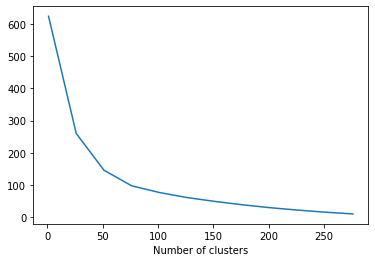

In [39]:
# Let's map the inertia for different number of clusters to find the optimal number of clusters
# We'll plot it to see the elbow
inertia = []
clusters = 300
step = 25
max_iter = 50
n_init = 5
random_state = 42
for k in range(1, clusters, step):
    kmeans = KMeans(
        n_clusters=k,
        max_iter=max_iter,
        n_init=n_init,
        random_state=random_state
    ).fit(X_lsa)
    # inertia is the sum of squared distances to the closest cluster center
    inertia.append(kmeans.inertia_)
plt.plot(range(1, clusters, step), inertia)
plt.xlabel('Number of clusters')

There appears to be an elbow about 50, so we'll use 50 clusters.

In [40]:
n_clusters = 50
max_iter = 50
n_init = 5
random_state = 42
kmeans = KMeans(
    n_clusters=n_clusters,
    max_iter=max_iter,
    n_init=n_init,
    random_state=random_state
).fit(X_lsa)

In [41]:
# create a new column `title_cluster` and assign it the kmeans cluster labels
# First we need to map the labels to df_unique_articles article ids and then apply those to df
article_cluster_map = dict(
    zip(df_unique_articles['article_id'], kmeans.labels_)
) # Map article_id to cluster label
df['title_cluster'] = df['article_id'].map(article_cluster_map) # apply map to create title clusters

In [42]:
# Let's check the number of articles in each cluster
np.array(np.unique(kmeans.labels_, return_counts=True)).T

array([[ 0,  7],
       [ 1, 13],
       [ 2, 23],
       [ 3, 18],
       [ 4, 11],
       [ 5, 30],
       [ 6, 68],
       [ 7,  7],
       [ 8, 15],
       [ 9, 20],
       [10,  8],
       [11, 28],
       [12, 20],
       [13,  9],
       [14,  8],
       [15, 35],
       [16, 17],
       [17, 10],
       [18,  7],
       [19, 15],
       [20, 12],
       [21,  5],
       [22, 11],
       [23,  9],
       [24, 10],
       [25, 18],
       [26, 19],
       [27,  7],
       [28, 22],
       [29, 13],
       [30, 14],
       [31, 20],
       [32,  8],
       [33, 20],
       [34, 42],
       [35, 11],
       [36,  7],
       [37,  9],
       [38,  5],
       [39,  7],
       [40,  8],
       [41,  6],
       [42,  6],
       [43, 11],
       [44,  8],
       [45,  8],
       [46,  4],
       [47,  7],
       [48,  8],
       [49, 10]], dtype=int64)

In [43]:
def get_similar_articles(article_id, df=df):
    """
    INPUT:
    article_id - (int) an article id 
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    article_ids - (list) a list of article ids that are in the same title cluster
    
    Description:
    Returns a list of the article ids that are in the same title cluster
    """
     # Your code here
    # Get cluster of the input article
    title_cluster = df[df['article_id'] == article_id]['title_cluster'].iloc[0]

    # Get all articles in same cluster
    articles_in_cluster = df[df['title_cluster'] == title_cluster]['article_id'].unique().tolist()

    # Remove the input article_id from the list
    articles_in_cluster = [aid for aid in articles_in_cluster if aid != article_id]
    
    
    return articles_in_cluster

In [44]:
def make_content_recs(article_id, n, df=df):
    """
    INPUT:
    article_id - (int) an article id
    n - (int) the number of recommendations you want similar to the article id
    df - (pandas dataframe) df as defined at the top of the notebook
    
    OUTPUT:
    n_ranked_similar_articles - (list) a list of article ids that are in the same title cluster ranked
                                by popularity
    n_ranked_article_names - (list) a list of article names associated with the list of article ids
    
    Description:
    Returns a list of the n most ranked similar articles to a given article_id based on the title
    cluster in df. Rank similar articles using the function get_ranked_article_unique_counts.
    """
    # Your code here
    # Get articles in same cluster
    similar_articles = get_similar_articles(article_id, df)

    # Rank them by popularity (using user_item matrix)
    ranked_articles = get_ranked_article_unique_counts(similar_articles)

    # Extract only article_ids in ranked order
    ranked_article_ids = [aid for aid, _ in ranked_articles]

    # Select top n
    n_ranked_similar_articles = ranked_article_ids[:n]

    # Get corresponding names
    n_ranked_article_names = get_article_names(n_ranked_similar_articles)
    
    return n_ranked_similar_articles, n_ranked_article_names
        

In [45]:
# Test out your content recommendations given artice_id 25
rec_article_ids, rec_article_titles = make_content_recs(25, 10)
print(rec_article_ids)
print(rec_article_titles)

[1025, 101, 975, 766, 508, 547, 132, 878, 92, 693]
['data tidying in data science experience', 'how to choose a project to practice data science', 'the data science process', 'making data science a team sport', 'data science in the cloud', 'trust in data science', 'collecting data science cheat sheets', '10 data science podcasts you need to be listening to right now', '9 mistakes to avoid when starting your career in data science', 'better together: spss and data science experience']


In [46]:
assert len({1025, 593, 349, 821, 464, 29, 1042, 693, 524, 352}.intersection(set(rec_article_ids))) > 0, "Oops! Your the make_content_recs function doesn't work quite how we expect."

`2.` Now that you have put together your content-based recommendation system, use the cell below to write a summary explaining how your content based recommender works.  Do you see any possible improvements that could be made to your function? What other text data would be useful to help make better recommendations besides the article title?

Content-Based Recommendation System Summary

The content-based recommender works by grouping articles according to the similarity of their titles and then recommending related articles from the same group.

First, we extracted unique article titles and applied TF-IDF vectorization to convert the text into numerical feature vectors. TF-IDF captures the importance of words within each title while reducing the influence of very common words.

Next, we applied Latent Semantic Analysis (LSA) using Truncated SVD to reduce dimensionality and uncover latent semantic structure in the titles. This helps group titles that are semantically similar, even if they do not share identical words.

After dimensionality reduction, we used KMeans clustering to cluster articles into groups based on their semantic similarity. Each article was assigned a title_cluster label.

When generating recommendations for a given article:

We identify its cluster.

We retrieve other articles in the same cluster.

We rank those articles by popularity (number of unique user interactions).

We return the top n ranked articles as recommendations.

This ensures that recommendations are:

Topically similar (cluster-based)

Popular among users (interaction-based ranking)

Possible Improvements

There are several ways this system could be improved:

Use richer text data
Currently, we only use article titles. Titles are short and may not fully capture article meaning. Better text sources would include:

Full article body text

Article summaries

Tags or categories

Author information

Keywords or metadata

Use advanced text embeddings
Instead of TF-IDF + LSA, we could use:

Word2Vec

Doc2Vec

BERT or Sentence Transformers
These methods capture deeper semantic meaning and context.

Hybrid approach
Combine content-based recommendations with collaborative filtering:

Use content similarity for cold-start

Transition to collaborative filtering as user interaction data grows

Personalized content filtering
Instead of recommending articles similar to a single article, we could:

Aggregate embeddings of all articles a user has read

Recommend articles closest to the user’s content profile

Conclusion

The current content-based recommender provides a simple and interpretable approach using clustering on article titles. While effective for basic similarity-based recommendations and cold-start scenarios, it could be significantly improved with richer textual features and more advanced embedding techniques

### <a class="anchor" id="Matrix-Fact">Part V: Matrix Factorization</a>

In this part of the notebook, you will build use matrix factorization to make article recommendations to users.

`1.` You should have already created a **user_item** matrix above in **question 1** of **Part III** above.  This first question here will just require that you run the cells to get things set up for the rest of **Part V** of the notebook. 

In [47]:
# quick look at the matrix
user_item.head()

article_id,0,2,4,8,9,12,14,15,16,18,...,1434,1435,1436,1437,1439,1440,1441,1442,1443,1444
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


`2.` In this situation, you can use Singular Value Decomposition from [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) on the user-item matrix.  Use the cell to perform SVD.

In [48]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import precision_score, recall_score, accuracy_score
# Using the full number of components which equals the number of columns
svd = TruncatedSVD(n_components=len(user_item.columns), n_iter=5, random_state=42)

u = svd.fit_transform(user_item)
v = svd.components_
s = svd.singular_values_ 
print('u', u.shape)
print('s', s.shape)
print('vt', v.shape)

u (5149, 714)
s (714,)
vt (714, 714)


`3.` Now for the tricky part, how do we choose the number of latent features to use?  Running the below cell, you can see that as the number of latent features increases, we obtain better metrics when making predictions for the 1 and 0 values in the user-item matrix.  Run the cell below to get an idea of how our metrics improve as we increase the number of latent features.

Text(0.5, 1.0, 'Metrics vs. Number of Latent Features')

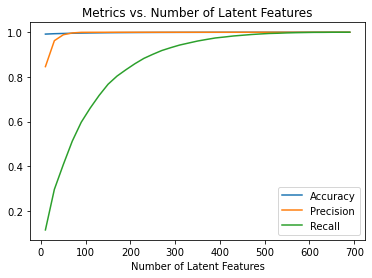

In [49]:
num_latent_feats = np.arange(10, 700+10, 20)
metric_scores = []

for k in num_latent_feats:
    # restructure with k latent features
    u_new, vt_new = u[:, :k], v[:k, :]
    
    # take dot product
    user_item_est = abs(np.around(np.dot(u_new, vt_new))).astype(int)
    # make sure the values are between 0 and 1
    user_item_est = np.clip(user_item_est, 0, 1)
    
    # total errors and keep track of them
    acc = accuracy_score(user_item.values.flatten(), user_item_est.flatten())
    precision = precision_score(user_item.values.flatten(), user_item_est.flatten())
    recall = recall_score(user_item.values.flatten(), user_item_est.flatten())
    metric_scores.append([acc, precision, recall])
    
    
plt.plot(num_latent_feats, metric_scores, label=['Accuracy', 'Precision', 'Recall'])
plt.legend()
plt.xlabel('Number of Latent Features')
plt.title('Metrics vs. Number of Latent Features')

`4.` From the above, we can't really be sure how many features to use, because simply having a better way to predict the 1's and 0's of the matrix doesn't exactly give us an indication of if we are able to make good recommendations. Given the plot above, what would you pick for the number of latent features and why?

A reasonable choice would be around 50–100 latent features.

From the plot, we can see:

Accuracy and precision increase quickly at first, then plateau.

Recall improves more gradually but also begins to level off.

After a certain number of latent features, the improvement becomes marginal.

This indicates diminishing returns, adding more features increases model complexity without providing significant gains in predictive performance.

Therefore, selecting a value in the range of 50–100 latent features balances:

Capturing meaningful structure in the data

Avoiding unnecessary complexity

Reducing risk of overfitting

In practice, I would choose a point just before the curves clearly flatten — where performance stabilizes but complexity is still moderate.

`5.` Using 200 latent features and the values of U, S, and V transpose we calculated above, create an article id recommendation function that finds similar article ids to the one provide.

Create a list of 10 recommendations that are similar to article with id 4.  The function should provide these recommendations by finding articles that have the most similar latent features as the provided article.

In [50]:
def get_svd_similar_article_ids(article_id, vt, user_item=user_item, include_similarity=False):
    """
    INPUT:
    article_id - (int) an article id
    vt - (numpy array) vt matrix from SVD
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    include_similarity - (bool) whether to include the similarity in the output
    
    OUTPUT:
    article_ids - (list) a list of article ids that are in the same title cluster
    
    Description:
    Returns a list of the article ids similar using SVD factorization
    """
    # Get list of article_ids in correct order (same as columns in user_item)
    article_ids = list(user_item.columns)

    # Find index of the given article_id
    article_idx = article_ids.index(article_id)

    # Transpose vt so rows correspond to articles
    article_features = vt.T  # shape: (n_articles, n_latent_features)

    # Compute cosine similarity between articles
    cos_sim = cosine_similarity(article_features)

    # Get similarity scores for the given article
    sim_scores = cos_sim[article_idx]

    # Get sorted indices (descending similarity)
    sorted_indices = np.argsort(sim_scores)[::-1]

    # Remove the article itself
    sorted_indices = sorted_indices[sorted_indices != article_idx]

    # Get corresponding article_ids
    most_similar_items = [article_ids[i] for i in sorted_indices]

    if include_similarity:
        return [[article_ids[i], sim_scores[i]] for i in sorted_indices]

    return most_similar_items

In [51]:
# Create a vt_new matrix with 200 latent features
k = 200
vt_new = v[:k, :]

In [52]:
# What is the article name for article_id 4?
print("Current article:", get_article_names([4], df=df)[0])

Current article: analyze ny restaurant data using spark in dsx


In [53]:
# What are the top 10 most similar articles to article_id 4?
rec_articles = get_svd_similar_article_ids(4, vt_new, user_item=user_item)[:10]
rec_articles

[1199, 1068, 486, 1202, 176, 1120, 244, 793, 58, 132]

In [54]:
# What are the top 10 most similar articles to article_id 4?
get_article_names(rec_articles, df=df)

['country statistics: crude oil - exports',
 'airbnb data for analytics: athens reviews',
 'use spark r to load and analyze data',
 'country statistics: crude oil - proved reserves',
 'top analytics tools in 2016',
 'airbnb data for analytics: paris calendar',
 'notebooks: a power tool for data scientists',
 '10 powerful features on watson data platform, no coding necessary',
 'advancements in the spark community',
 'collecting data science cheat sheets']

In [55]:
assert set(rec_articles) == {1199, 1068, 486, 1202, 176, 1120, 244, 793, 58, 132}, "Oops! Your the get_svd_similar_article_ids function doesn't work quite how we expect."
print("That's right!  Great job!")

That's right!  Great job!


`6.` Use the cell below to comment on the results you found in the previous question. Given the circumstances of your results, discuss what you might do to determine if the recommendations you make above are an improvement to how users currently find articles, either by Sections 2, 3, or 4? Add any tradeoffs between each of the methods, and how you could leverage each type for different situations including new users with no history, recently new users with little history, and users with a lot of history. 

Discussion of Results and Recommendation Strategy

For article_id 4 (“analyze my restaurant data using spark in dsx”), the SVD-based recommendations include Spark-related content (“use spark to load and analyze data”, “advancements in the spark community”) as well as broader analytics and data science topics. This suggests that the latent factor model successfully captured both direct technical similarity (Spark ecosystem) and broader data analytics relevance. The recommendations appear semantically reasonable rather than purely keyword-matched.

However, to determine whether these recommendations are actually better than those from Sections 2 (rank-based), 3 (collaborative filtering), or 4 (content clustering), we would need proper evaluation:

Offline evaluation: precision, recall, or holdout validation.

Online A/B testing: click-through rate, dwell time, engagement lift.

User behavior signals: saves, completion rate, repeat visits.

Better prediction of matrix entries does not necessarily mean better user experience.

Tradeoffs Between Methods

Rank-Based (Popularity)

Robust and simple.

Best for new users (cold start).

Not personalized.

User-User Collaborative Filtering

Personalized via behavioral similarity.

Performs well for users with moderate history.

Struggles with sparse users.

Content-Based (Clustering)

Works without user history.

Limited by short titles and shallow text signals.

SVD (Matrix Factorization)

Captures latent behavioral structure.

Strong for users with rich history.

Less interpretable; requires enough data.

Practical Hybrid Strategy

New users (no history) : Popular + Content-based.

Light-history users : Content + Early collaborative filtering.

Heavy users : SVD-based personalization.

Combine methods via weighted ranking for stability.

A hybrid system would likely outperform any single approach across different user maturity stages.